In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize as op

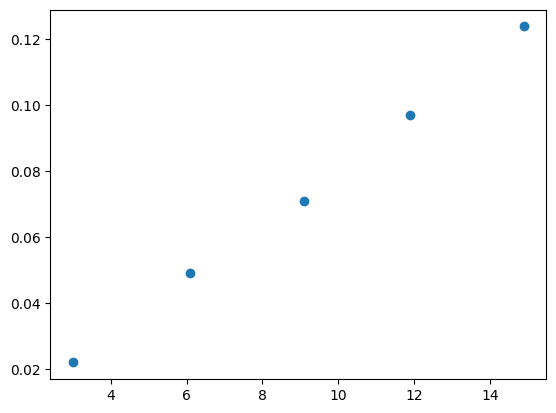

In [3]:
# 需要拟合的数据组
x_group = np.array([3, 6.1, 9.1, 11.9, 14.9])
y_group = np.array([0.0221, 0.0491, 0.0711, 0.0971, 0.1238])
plt.scatter(x_group, y_group)
plt.show()

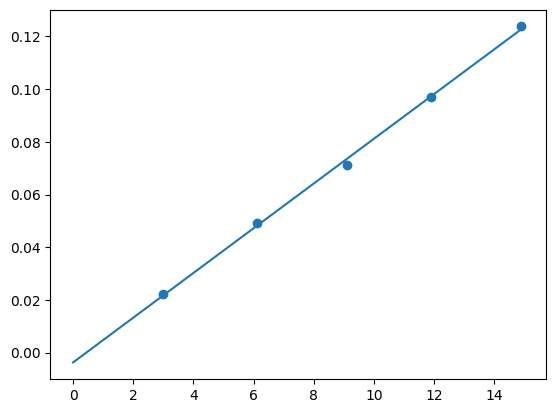

In [ ]:
# 需要拟合的函数
def f_1(x, A, B):
    return A * x + B

popt, _ = op.curve_fit(f_1, x_group, y_group)
A, B = popt

# 数据点与原来的进行画图比较
x = np.arange(0, 15, 0.01)
y = A * x + B

plt.plot(x, y)
plt.scatter(x_group, y_group)

plt.show()


[2.55423706 1.35190946 0.47450617]
[2.43708905 1.         0.35015434]


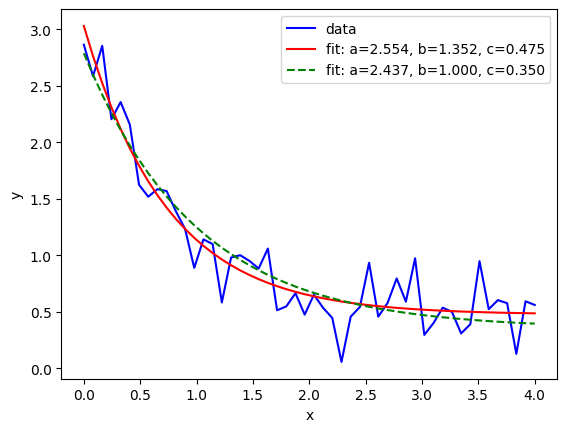

In [16]:
# 另外一个例子

# 定义需要拟合的函数
def func(x, a, b, c):
    return a * np.exp(-b * x) + c

# 用numpy的random库生成干扰
xdata = np.linspace(0, 4, 50)
y = func(xdata, 2.5, 1.3, 0.5)
np.random.seed(1729)
y_noise = 0.2 * np.random.normal(size=xdata.size)
ydata = y + y_noise
plt.plot(xdata, ydata, 'b-', label='data')

popt, pcov = op.curve_fit(func, xdata, ydata)
print(popt)
plt.plot(xdata, func(xdata, *popt), 'r-',
         label='fit: a=%5.3f, b=%5.3f, c=%5.3f' % tuple(popt))

# Constrain the optimization to the region of 0 <= a <= 3, 0 <= b <= 1 and 0 <= c <= 0.5:
# 限定范围进行拟合
popt, pcov = op.curve_fit(func, xdata, ydata, bounds=(0, [3., 1., 0.5]))
print(popt)

plt.plot(xdata, func(xdata, *popt), 'g--',
         label='fit: a=%5.3f, b=%5.3f, c=%5.3f' % tuple(popt))
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# 通过最小二乘法来拟合函数超参